In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

pandas: 3.0.3
numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2


In [5]:
import pandas as pd

# Load your downloaded file
# Replace the path below with your actual file location
df = pd.read_csv(r"C:\Users\USER\Downloads\HDX\health_facilities_nigeria.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (46146, 15)

Columns: ['id', 'name', 'global_id', 'alternate_name', 'functional_status', 'type', 'ward_code', 'category', 'timestamp', 'accessibility', 'lga_name', 'lga_code', 'state_code', 'state_name', 'FID']

First 5 rows:


,id,name,global_id,alternate_name,functional_status,type,ward_code,category,timestamp,accessibility,lga_name,lga_code,state_code,state_name,FID
0,1,G R A Nursing Home,af719462-abfd-4f47-9dc3-0987164e75ac,Nursing Home,Unknown,Primary,12413,Primary Health Center,2020-07-04T13:49:18Z,NaN,Maiduguri,124,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
1,2,Gishili Health Center,a29b0328-d844-4358-b0ab-2e120b8fb30f,Nursing Home,Functional,Primary,12413,Primary Health Center,2020-07-04T13:49:18Z,Unknown,Maiduguri,124,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
2,3,Lehobi Primary Health Care,b685b769-5c83-4f83-a182-00e7e1b777d8,NaN,Partially Functional,Primary,10207,Primary Health Center,2020-07-04T13:49:18Z,NaN,Askira Uba,102,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
3,4,Dugja Idp Camp,78e64f7a-cbb8-4357-9e64-a7e502534527,Mandara Girau Dispensary,Not Functional,Primary,10503,Primary Health Center,2020-07-04T13:49:18Z,Unknown,Biu,105,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
4,5,Kopa Maikudiri Dispensary,409c97ce-7490-4dc2-a8f8-2b8d53ad2b12,NaN,Partially Functional,Primary,10209,Dispensary,2020-07-04T13:49:18Z,Unknown,Askira Uba,102,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...


In [6]:
# Step 1 — How many facilities per state?
print("=== FACILITIES PER STATE ===")
print(df['state_name'].value_counts())

=== FACILITIES PER STATE ===
state_name
Lagos          2320
Katsina        2228
Benue          2192
Niger          2010
Ogun           1721
Oyo            1713
Imo            1661
Anambra        1648
Osun           1607
Adamawa        1575
Kano           1561
Kogi           1499
Cross River    1470
Enugu          1384
Taraba         1380
Plateau        1348
Bauchi         1331
Abia           1218
Nasarawa       1126
Ebonyi         1112
Kaduna         1103
Kebbi          1091
Ondo           1025
Edo             972
Zamfara         916
Sokoto          914
Delta           909
Kwara           891
Borno           884
Akwa Ibom       870
Gombe           776
Jigawa          729
Rivers          723
Ekiti           679
Yobe            597
Fct             576
Bayelsa         387
Name: count, dtype: int64


In [ ]:
# Step 2 — What are the functional status categories?
print("=== FUNCTIONAL STATUS ===")
print(df['functional_status'].value_counts())

In [8]:
# Step 2 — What are the functional status categories?
print("=== FUNCTIONAL STATUS ===")
print(df['functional_status'].value_counts())

=== FUNCTIONAL STATUS ===
functional_status
Functional              34282
Unknown                 11753
Not Functional            104
Partially Functional        7
Name: count, dtype: int64


In [9]:
# Step 3 — What facility categories exist?
print("=== FACILITY CATEGORIES ===")
print(df['category'].value_counts())

=== FACILITY CATEGORIES ===
category
Primary Health Center               28031
Dispensary                           8626
Maternity Home                       4423
Private Non Profit                   1179
Medical Center                        956
Specialist Hospital                   673
General Hospital                      637
Comprehensive Health Center           458
Educational Clinic                    249
Laboratory                            234
Cottage Hospital                      223
Military and Paramilitary Clinic      143
Federal Staff Clinic                  110
Teaching Hospital                      51
Federal Medical Center                 46
District Hospital                      25
Pharmacy                               21
Veterinary Clinic                      14
Community Health Center                 8
Others                                  4
Research Hospital                       1
Name: count, dtype: int64


In [10]:
# Step 4 — How much missing data do we have?
print("=== MISSING VALUES PER COLUMN ===")
print(df.isnull().sum())

=== MISSING VALUES PER COLUMN ===
id                       0
name                     0
global_id                0
alternate_name       42120
functional_status        0
type                     0
ward_code                0
category                34
timestamp                0
accessibility        46012
lga_name                 0
lga_code                 0
state_code            1126
state_name               0
FID                      0
dtype: int64


In [11]:
# Step 1 — Drop columns we don't need for analysis
df = df.drop(columns=['global_id', 'ward_code', 'lga_code', 'state_code', 'FID', 'timestamp'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['id', 'name', 'alternate_name', 'functional_status', 'type', 'category', 'accessibility', 'lga_name', 'state_name']


In [12]:
# Step 2 — Standardise text columns — strip spaces, fix casing
df['state_name'] = df['state_name'].str.strip().str.title()
df['lga_name'] = df['lga_name'].str.strip().str.title()
df['functional_status'] = df['functional_status'].str.strip().str.title()
df['category'] = df['category'].str.strip().str.title()
df['type'] = df['type'].str.strip().str.title()
df['accessibility'] = df['accessibility'].str.strip().str.title()
print("Text standardised.")

Text standardised.


In [13]:
# Step 3 — Replace 'Unknown' and 'Unknown' strings with NaN so we treat them as missing
import numpy as np
df['functional_status'] = df['functional_status'].replace('Unknown', np.nan)
df['accessibility'] = df['accessibility'].replace('Unknown', np.nan)
print("Unknown values replaced.")

Unknown values replaced.


In [15]:
# Drop accessibility
df = df.drop(columns=['accessibility'])
print("Done. Shape:", df.shape)

Done. Shape: (46146, 7)


In [16]:
# Fill missing values
df['functional_status'] = df['functional_status'].fillna('Unknown')
df['category'] = df['category'].fillna('Unspecified')
print("Done. Missing values:")
print(df.isnull().sum())

Done. Missing values:
id                   0
name                 0
functional_status    0
type                 0
category             0
lga_name             0
state_name           0
dtype: int64


In [18]:
# Save cleaned file
df.to_csv(r"C:\Users\USER\Downloads\HDX\health_facilities_nigeria.csv", index=False)
print("Saved.")

Saved.


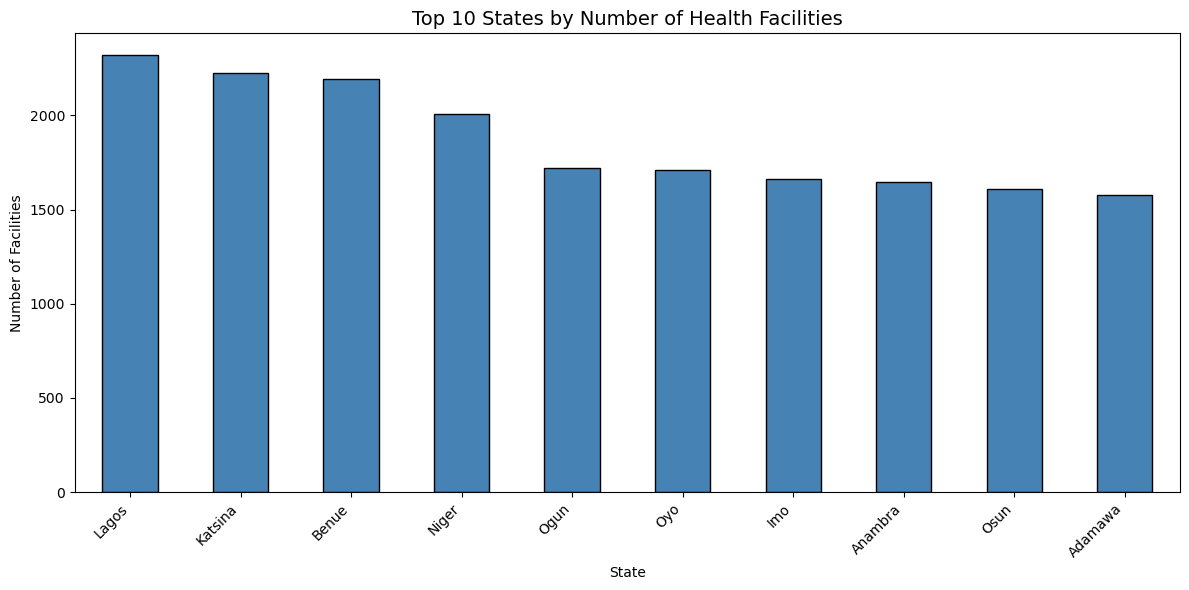

state_name
Lagos      2320
Katsina    2228
Benue      2192
Niger      2010
Ogun       1721
Oyo        1713
Imo        1661
Anambra    1648
Osun       1607
Adamawa    1575
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt

state_counts = df['state_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
state_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 States by Number of Health Facilities', fontsize=14)
plt.xlabel('State')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(state_counts)

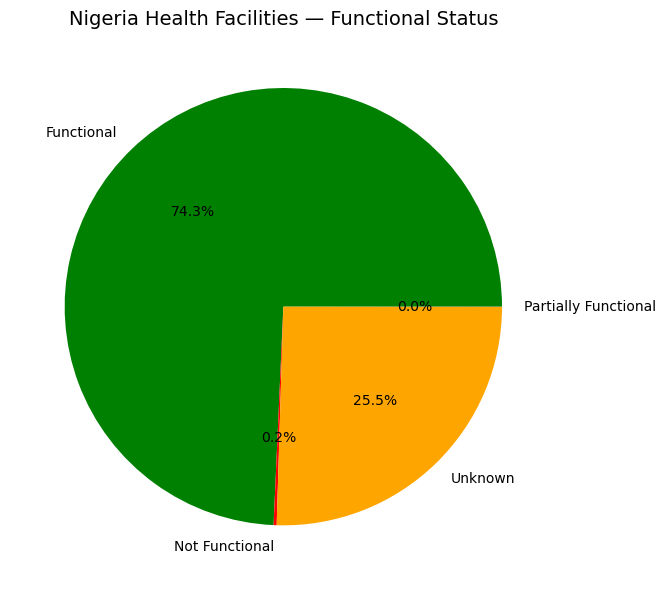

In [28]:
# Reorder manually to separate the small slices
desired_order = ['Functional', 'Not Functional', 'Unknown', 'Partially Functional']
status_counts = df['functional_status'].value_counts()
status_counts = status_counts.reindex(desired_order)

plt.figure(figsize=(8, 6))
status_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green', 'red', 'orange', 'grey']
)
plt.title('Nigeria Health Facilities — Functional Status', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

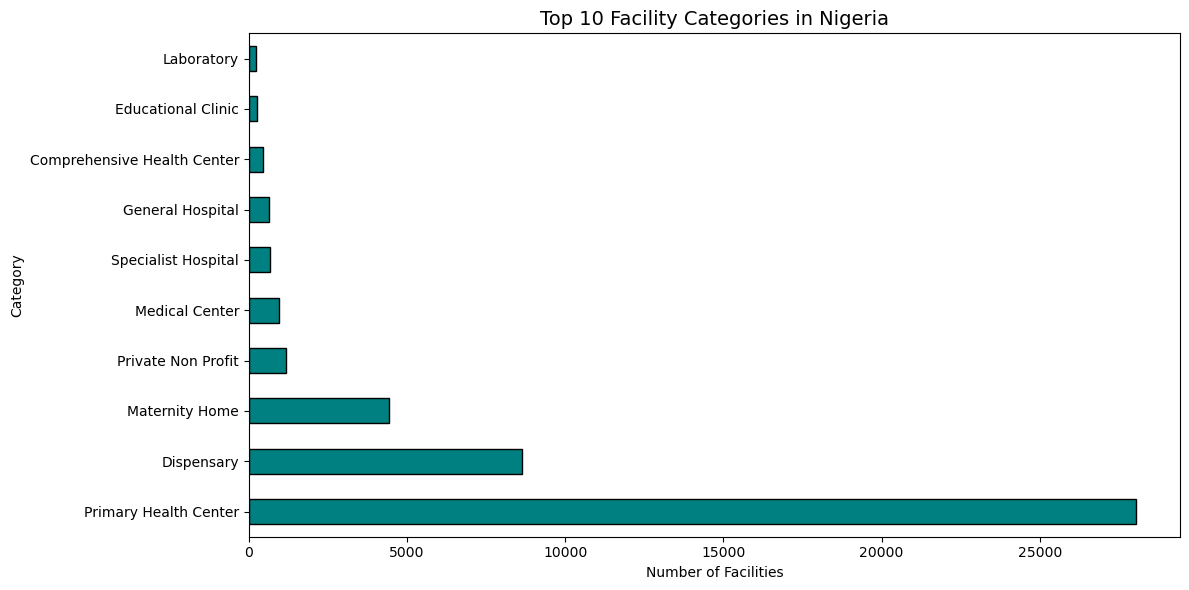

category
Primary Health Center          28031
Dispensary                      8626
Maternity Home                  4423
Private Non Profit              1179
Medical Center                   956
Specialist Hospital              673
General Hospital                 637
Comprehensive Health Center      458
Educational Clinic               249
Laboratory                       234
Name: count, dtype: int64


In [26]:
category_counts = df['category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
category_counts.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Facility Categories in Nigeria', fontsize=14)
plt.xlabel('Number of Facilities')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print(category_counts)

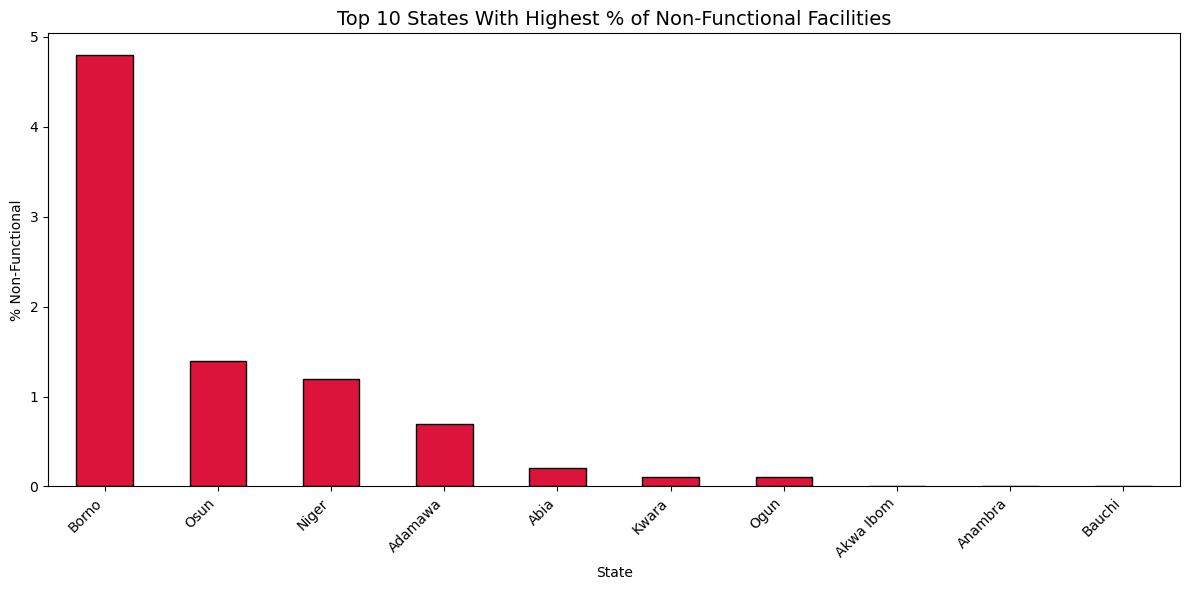

state_name
Borno        4.8
Osun         1.4
Niger        1.2
Adamawa      0.7
Abia         0.2
Kwara        0.1
Ogun         0.1
Akwa Ibom    0.0
Anambra      0.0
Bauchi       0.0
Name: pct_not_functional, dtype: float64


In [27]:
# Calculate functional status breakdown per state
status_by_state = df.groupby(['state_name', 'functional_status']).size().unstack(fill_value=0)

# Calculate % not functional per state
status_by_state['total'] = status_by_state.sum(axis=1)
status_by_state['pct_not_functional'] = (
    status_by_state.get('Not Functional', 0) / status_by_state['total'] * 100
).round(1)

# Top 10 worst states
worst_states = status_by_state['pct_not_functional'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
worst_states.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Top 10 States With Highest % of Non-Functional Facilities', fontsize=14)
plt.xlabel('State')
plt.ylabel('% Non-Functional')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(worst_states)

In [29]:
# Filter for Akwa Ibom
akwa_ibom = df[df['state_name'] == 'Akwa Ibom']

print("Total facilities in Akwa Ibom:", len(akwa_ibom))
print("\nBy category:")
print(akwa_ibom['category'].value_counts())
print("\nBy functional status:")
print(akwa_ibom['functional_status'].value_counts())
print("\nBy LGA:")
print(akwa_ibom['lga_name'].value_counts())

Total facilities in Akwa Ibom: 870

By category:
category
Primary Health Center               552
Dispensary                          144
Medical Center                       41
Private Non Profit                   33
Maternity Home                       27
Specialist Hospital                  23
General Hospital                     17
Cottage Hospital                     12
Comprehensive Health Center           9
Educational Clinic                    6
Military And Paramilitary Clinic      3
Teaching Hospital                     1
Federal Staff Clinic                  1
Pharmacy                              1
Name: count, dtype: int64

By functional status:
functional_status
Functional    790
Unknown        80
Name: count, dtype: int64

By LGA:
lga_name
Uyo                  74
Eket                 47
Ikot Ekpene          41
Obot Akara           40
Ibiono Ibom          36
Ukanafun             34
Ibesikpo Asutan      34
Ikot Abasi           32
Abak                 30
Mkpat Enin         

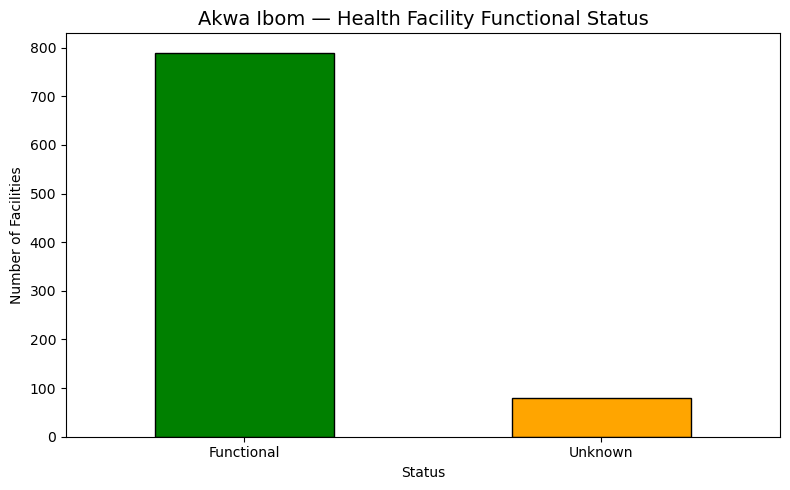

In [30]:
ak_status = akwa_ibom['functional_status'].value_counts()

plt.figure(figsize=(8, 5))
ak_status.plot(kind='bar', color=['green', 'orange', 'red', 'grey'], edgecolor='black')
plt.title('Akwa Ibom — Health Facility Functional Status', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

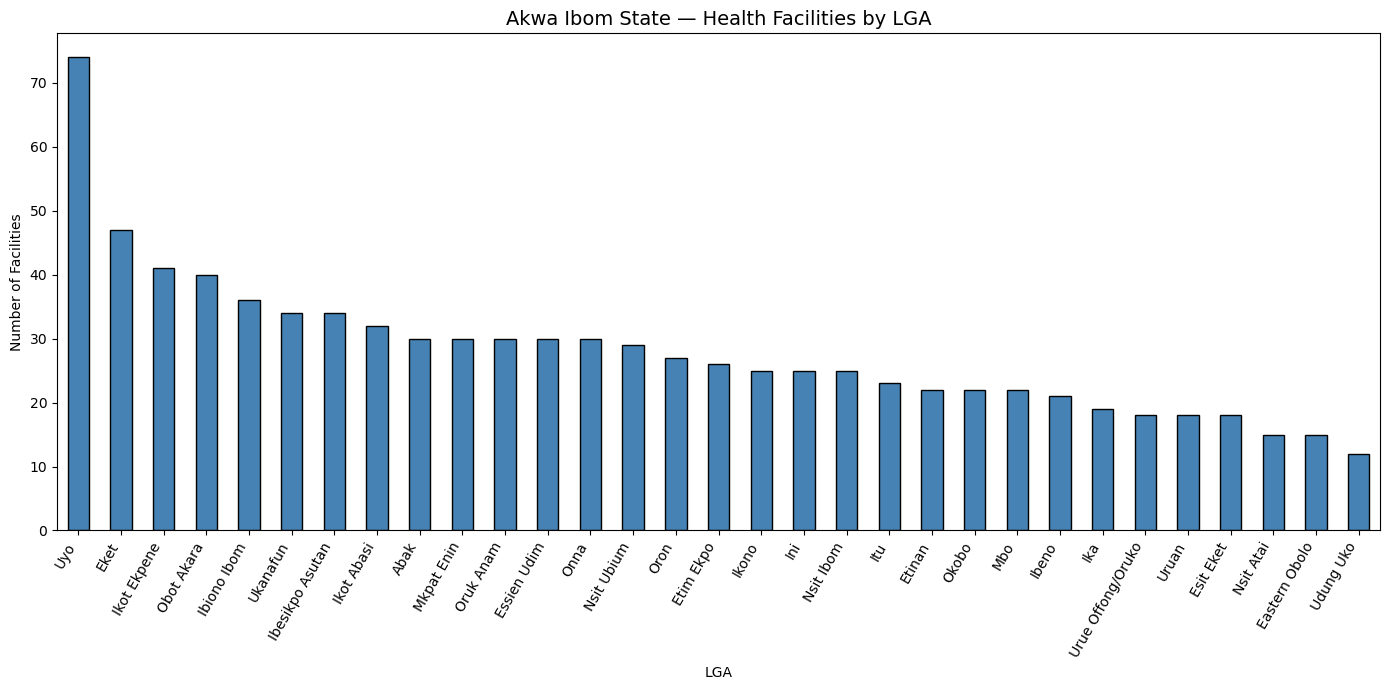

In [31]:
ak_lga = akwa_ibom['lga_name'].value_counts()

plt.figure(figsize=(14, 7))
ak_lga.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Akwa Ibom State — Health Facilities by LGA', fontsize=14)
plt.xlabel('LGA')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

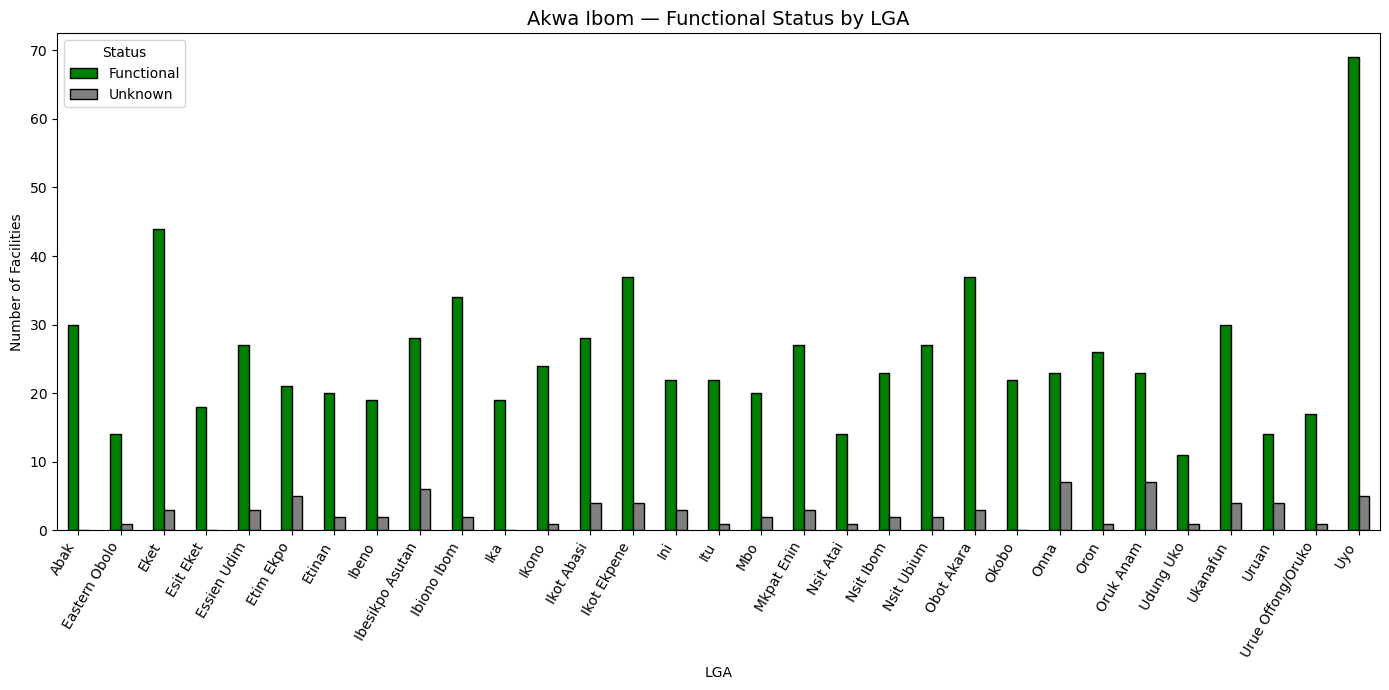

In [32]:
ak_status_lga = akwa_ibom.groupby(['lga_name', 'functional_status']).size().unstack(fill_value=0)

ak_status_lga.plot(kind='bar', figsize=(14, 7), edgecolor='black',
                   color=['green', 'grey'])
plt.title('Akwa Ibom — Functional Status by LGA', fontsize=14)
plt.xlabel('LGA')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

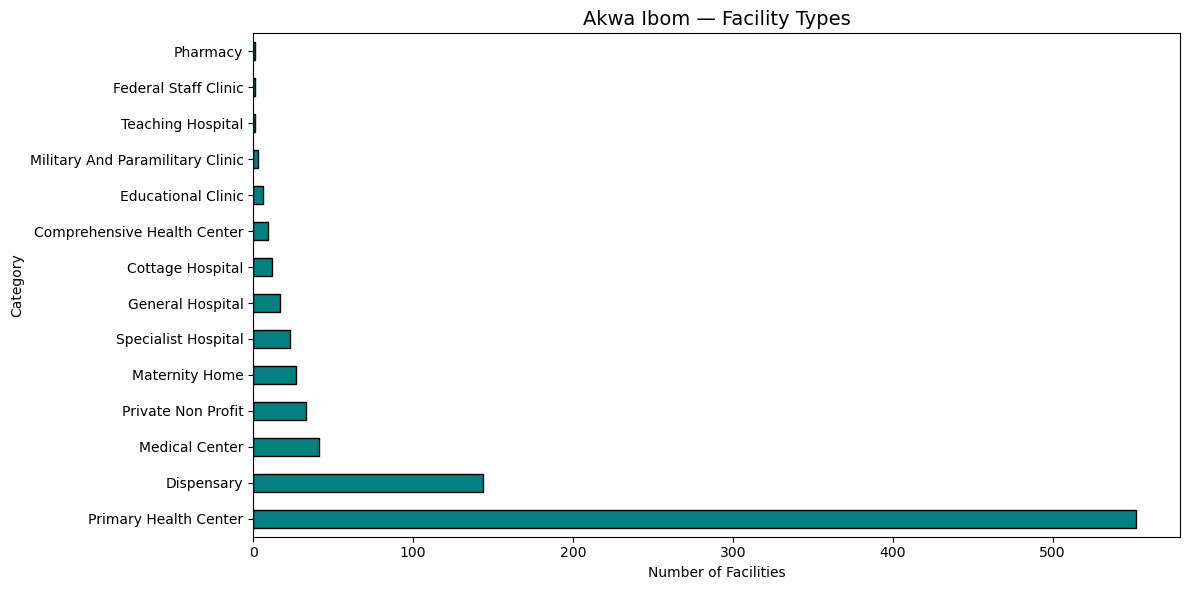

In [33]:
ak_category = akwa_ibom['category'].value_counts()

plt.figure(figsize=(12, 6))
ak_category.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Akwa Ibom — Facility Types', fontsize=14)
plt.xlabel('Number of Facilities')
plt.ylabel('Category')
plt.tight_layout()
plt.show()